# Proyek Analisis Data: Bike Sharing Dataset
- **Nama:** Olivia Fernando
- **Email:** oliviafernandoo@gmail.com
- **ID Dicoding:** CDCC922D6X0136

## Menentukan Pertanyaan Bisnis

## Import Semua Packages/Library yang Digunakan

1. Bagaimana pengaruh musim terhadap jumlah penyewaan sepeda?
2. Bagaimana pengaruh suhu terhadap jumlah penyewaan sepeda?

In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Data Wrangling

### Gathering Data

In [34]:
day_df = pd.read_csv("day.csv")
hour_df = pd.read_csv("hour.csv")

day_df.head()
hour_df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


**Insight:**
- Dataset terdiri dari dua file yaitu day.csv dan hour.csv.
- Dataset berisi informasi penyewaan sepeda berdasarkan waktu, cuaca, dan kondisi kalender.
- Dataset ini dapat digunakan untuk menganalisis pola penyewaan sepeda berdasarkan berbagai faktor seperti musim dan suhu.

### Assessing Data

In [35]:
day_df.info()
day_df.isna().sum()
day_df.duplicated().sum()

hour_df.info()
hour_df.isna().sum()
hour_df.duplicated().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (tot

np.int64(0)

**Insight:**
- Dataset day.csv memiliki 731 baris data sedangkan hour.csv memiliki 17379 baris data.
- Tidak ditemukan missing value pada kedua dataset.
- Tidak terdapat data duplikat pada dataset.
- Kolom dteday masih bertipe object sehingga perlu diubah menjadi tipe datetime pada tahap cleaning data.

### Cleaning Data

In [36]:
# Mengubah tipe data tanggal
day_df["dteday"] = pd.to_datetime(day_df["dteday"])
hour_df["dteday"] = pd.to_datetime(hour_df["dteday"])

# Verifikasi hasil perubahan
day_df.info()
hour_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   instant     731 non-null    int64         
 1   dteday      731 non-null    datetime64[ns]
 2   season      731 non-null    int64         
 3   yr          731 non-null    int64         
 4   mnth        731 non-null    int64         
 5   holiday     731 non-null    int64         
 6   weekday     731 non-null    int64         
 7   workingday  731 non-null    int64         
 8   weathersit  731 non-null    int64         
 9   temp        731 non-null    float64       
 10  atemp       731 non-null    float64       
 11  hum         731 non-null    float64       
 12  windspeed   731 non-null    float64       
 13  casual      731 non-null    int64         
 14  registered  731 non-null    int64         
 15  cnt         731 non-null    int64         
dtypes: datetime64[ns](1), floa

**Insight:**
- Kolom dteday pada dataset awalnya bertipe object.
- Kolom tersebut kemudian dikonversi menjadi tipe datetime menggunakan fungsi pd.to_datetime().
- Perubahan ini dilakukan agar data tanggal dapat digunakan dalam analisis berbasis waktu.

## Exploratory Data Analysis (EDA)

### Explore ...

In [37]:
day_df.describe()
day_df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


**Insight:**
- Dataset memiliki 731 data harian penyewaan sepeda.
- Tidak terdapat missing value pada dataset.
- Variabel cnt menunjukkan total jumlah penyewaan sepeda.

## Visualization & Explanatory Analysis

### Pertanyaan 1:

In [38]:
# Mengubah angka season jadi nama musim
season_mapping = {
    1: "Spring",
    2: "Summer",
    3: "Fall",
    4: "Winter"
}

day_df["season"] = day_df["season"].map(season_mapping)

# Total penyewaan sepeda berdasarkan musim
season_rentals = day_df.groupby("season")["cnt"].sum().sort_values(ascending=False)

season_rentals

,cnt
season,
Fall,1061129
Summer,918589
Winter,841613
Spring,471348


### Pertanyaan 2:

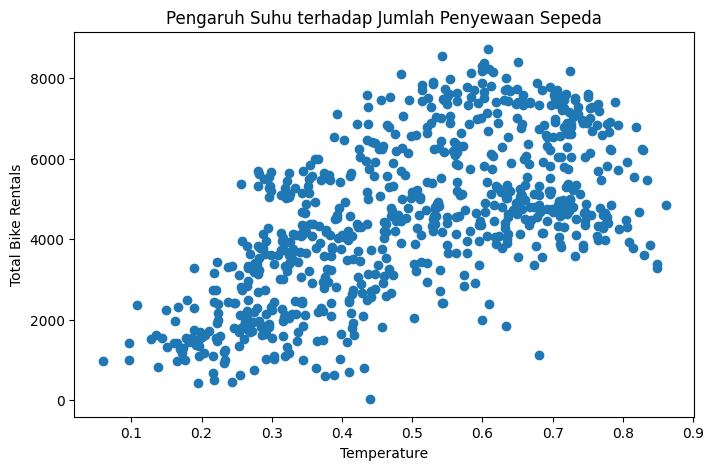

In [39]:
# Melihat rata-rata penyewaan sepeda berdasarkan suhu
day_df.groupby("temp")["cnt"].mean().head()

# Visualisasi hubungan suhu dengan jumlah penyewaan sepeda
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.scatter(day_df["temp"], day_df["cnt"])

plt.xlabel("Temperature")
plt.ylabel("Total Bike Rentals")
plt.title("Pengaruh Suhu terhadap Jumlah Penyewaan Sepeda")

plt.show()

**Insight pertanyaan 1:**
- Musim Fall (Gugur) memiliki jumlah penyewaan sepeda paling tinggi.
- Musim Spring (semi) memiliki jumlah penyewaan sepeda paling rendah.
- Hal ini menunjukkan bahwa kondisi cuaca pada musim tertentu dapat mempengaruhi minat masyarakat dalam menyewa sepeda.

**Insight Pertanyaan 2:**
- Terdapat hubungan positif antara suhu dan jumlah penyewaan sepeda.
- Semakin tinggi suhu, jumlah penyewaan sepeda cenderung meningkat.
- Hal ini kemungkinan karena masyarakat lebih nyaman beraktivitas di luar ruangan ketika suhu lebih hangat.

## Analisis Lanjutan (Opsional)

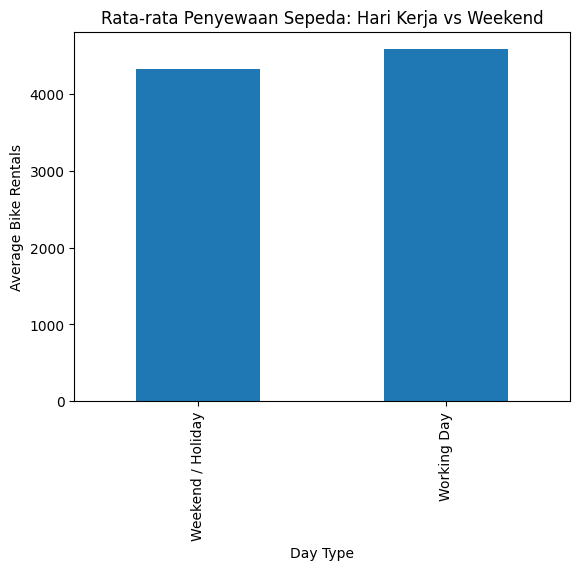

In [40]:
# Mengubah workingday menjadi label yang lebih jelas
workingday_mapping = {
    0: "Weekend / Holiday",
    1: "Working Day"
}

day_df["workingday"] = day_df["workingday"].map(workingday_mapping)

# Menghitung rata-rata penyewaan sepeda berdasarkan jenis hari
workingday_rentals = day_df.groupby("workingday")["cnt"].mean()

workingday_rentals

# Visualisasi
import matplotlib.pyplot as plt

workingday_rentals.plot(kind="bar")

plt.title("Rata-rata Penyewaan Sepeda: Hari Kerja vs Weekend")
plt.xlabel("Day Type")
plt.ylabel("Average Bike Rentals")

plt.show()

## Conclusion

**Berdasarkan hasil analisis data penyewaan sepeda, diperoleh beberapa kesimpulan berikut:**

1. Musim Fall memiliki jumlah penyewaan sepeda tertinggi dibandingkan musim lainnya, sedangkan musim Spring memiliki jumlah penyewaan paling rendah. Hal ini menunjukkan bahwa kondisi cuaca pada musim tertentu dapat mempengaruhi minat masyarakat dalam menyewa sepeda.

2. Suhu memiliki hubungan positif dengan jumlah penyewaan sepeda. Semakin tinggi suhu, jumlah penyewaan sepeda cenderung meningkat. Hal ini kemungkinan karena masyarakat lebih nyaman beraktivitas di luar ruangan ketika suhu lebih hangat.

In [41]:
main_data = day_df[[
    "dteday",
    "season",
    "workingday",
    "temp",
    "hum",
    "windspeed",
    "cnt"
]]

main_data.to_csv("main_data.csv", index=False)